# 02 · Sistema ELO

El núcleo del modelo de predicción es un **sistema ELO** construido desde cero.
ELO es un método de rating que asigna un número a cada equipo según su historial
de resultados. La diferencia entre ratings permite calcular la probabilidad de
victoria antes de cada partido.

Este notebook cubre:
1. Calibración del parámetro `HOME_ADVANTAGE` desde los datos
2. Implementación del sistema ELO sobre 1999–2025
3. Validación mediante análisis de Super Bowls históricos
4. Backtesting del `HOME_ADVANTAGE` con Brier Score
5. Comparación contra el benchmark de Vegas
6. Visualizaciones de los rating

## §1 · Setup

In [73]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## §2 · Calibración de HOME_ADVANTAGE

El sistema ELO trata el **home advantage** como un bonus de puntos ELO que se
suma al equipo local antes de calcular la probabilidad esperada.

En lugar de tomar un valor de referencia externo, lo calibramos directamente
desde el **home win rate observado en nuestros datos**.

La derivación matemática es la siguiente:

Si ambos equipos tienen el mismo rating ELO, la probabilidad de victoria local es:

    P_home = 1 / (1 + 10^(-HA/400))

Despejando HA a partir del win rate observado:

    HA = -400 × log₁₀((1/WR) - 1)

Analizamos distintas ventanas temporales para entender si el home advantage
ha cambiado a lo largo del tiempo.

In [ ]:
COLS_TO_DROP = ['nfl_detail_id', 'pff', 'ftn', 'away_spread_odds', 'home_spread_odds','over_odds', 'under_odds']

FRANCHISE_MAP = {
    
    # Rams
    "STL": "LA",
    "LA": "LA",
    "LAR": "LA",

    # Raiders
    "OAK": "LV",
    "LV": "LV",
    "LVR": "LV",

    # Chargers
    "SD": "LAC",
    "LAC": "LAC"
}

# Function to load and preprocess NFL data for given seasons
def load_nfl_data(seasons, cols_to_drop = COLS_TO_DROP, franchise_map = FRANCHISE_MAP):
    
    df = nfl.import_schedules(seasons)
    df = df.drop(columns=cols_to_drop)
    df["home_team"] = df["home_team"].replace(franchise_map)
    df["away_team"] = df["away_team"].replace(franchise_map)
    df['home_team_win'] = (df['home_score'] > df['away_score']).astype(int)
    
    
    return df

In [60]:
# ── Constantes del sistema ─────────────────────────────────────────────────────

ELO_INICIAL    = 1500
K_REGULAR      = 20
K_PLAYOFFS     = 24
REGRESION      = 0.33
MEDIA_GLOBAL   = 1505

GAME_TYPE_K = {
    'REG': K_REGULAR,
    'WC' : K_PLAYOFFS,
    'DIV': K_PLAYOFFS,
    'CON': K_PLAYOFFS,
    'SB' : K_PLAYOFFS,
}


# ── Función 1: HOME_ADVANTAGE ──────────────────────────────────────────────────

def estimate_home_advantage(df, last_n_seasons=None, game_types=['REG']):
    """
    Calibra HOME_ADVANTAGE desde el home win rate observado.
    HA = -400 * log10((1 / P_home) - 1)
    """
    mask = df['game_type'].isin(game_types)

    if last_n_seasons is not None:
        max_season = df['season'].max()
        min_season = max_season - last_n_seasons + 1
        mask = mask & (df['season'] >= min_season)

    subset = df[mask]
    observed_rate = subset['home_team_win'].mean()
    ha = -400 * np.log10((1 / observed_rate) - 1)

    return {
        'home_advantage': round(ha, 1),
        'home_win_rate' : round(observed_rate, 4),
        'n_games'       : len(subset),
        'seasons'       : (subset['season'].min(), subset['season'].max())
    }


# ── Función 2: probabilidad esperada ──────────────────────────────────────────

def expected_win_prob(elo_home, elo_away, home_advantage):
    """
    Calcula la probabilidad de victoria del equipo local.

    P_home = 1 / (1 + 10^(-((R_home - R_away + HA) / 400)))

    Parameters
    ----------
    elo_home       : float — rating ELO del equipo local
    elo_away       : float — rating ELO del equipo visitante
    home_advantage : float — puntos ELO de ventaja local (0 para SB)

    Returns
    -------
    float — probabilidad de victoria del local [0, 1]
    """
    diff = (elo_home - elo_away + home_advantage) / 400
    return 1 / (1 + 10 ** (-diff))


# ── Función 3: actualización de ratings ───────────────────────────────────────

def update_elo(elo_home, elo_away, result, k, home_advantage):
    """
    Actualiza los ratings ELO después de un partido.

    New_ELO_home = ELO_home + K * (S - P_home)
    New_ELO_away = ELO_away + K * ((1-S) - (1-P_home))

    Parameters
    ----------
    elo_home       : float — rating ELO del equipo local pre-partido
    elo_away       : float — rating ELO del equipo visitante pre-partido
    result         : int   — 1 si ganó local, 0 si ganó visitante
    k              : float — K-factor del partido
    home_advantage : float — puntos ELO de ventaja local (0 para SB)

    Returns
    -------
    tuple (new_elo_home, new_elo_away)
    """
    p_home = expected_win_prob(elo_home, elo_away, home_advantage)

    delta = k * (result - p_home)

    return (
        round(elo_home + delta, 4),
        round(elo_away - delta, 4),
    )


# ── Función 4: regresión entre temporadas ─────────────────────────────────────

def apply_season_regression(elo_ratings):
    """
    Jala todos los ratings hacia la media global al inicio de cada temporada.

    ELO_inicio = (1 - α) * ELO_final + α * MEDIA_GLOBAL

    Parameters
    ----------
    elo_ratings : dict — {team: elo_rating}

    Returns
    -------
    dict — {team: elo_rating_regresado}
    """
    return {
        team: round((1 - REGRESION) * elo + REGRESION * MEDIA_GLOBAL, 4)
        for team, elo in elo_ratings.items()
    }


# ── Función 5: sistema completo ───────────────────────────────────────────────

def run_elo_system(df, home_advantage):
    """
    Corre el sistema ELO sobre todo el histórico partido a partido.

    Parameters
    ----------
    df             : pd.DataFrame — schedules limpio (output de data_loader)
    home_advantage : float        — puntos ELO de ventaja local para REG/WC/DIV/CON
                                    SB siempre usa HA=0

    Returns
    -------
    history_df : pd.DataFrame — ELO de cada equipo antes y después de cada partido
    final_elos : dict         — {team: elo_final} al cierre del último season
    """
    # Ordenar por temporada y semana para garantizar orden cronológico
    df = df.sort_values(['season', 'week']).reset_index(drop=True)

    # Inicializar ratings
    teams     = set(df['home_team']).union(set(df['away_team']))
    elo_ratings = {team: ELO_INICIAL for team in teams}

    records = []
    current_season = None

    for _, row in df.iterrows():

        season    = row['season']
        game_type = row['game_type']
        home_team = row['home_team']
        away_team = row['away_team']
        result    = row['home_team_win']

        # ── Regresión al inicio de cada nueva temporada ──────────────────────
        if season != current_season:
            if current_season is not None:
                elo_ratings = apply_season_regression(elo_ratings)
            current_season = season

        # ── Parámetros del partido ────────────────────────────────────────────
        k  = GAME_TYPE_K[game_type]
        ha = 0.0 if game_type == 'SB' else home_advantage

        elo_home_pre = elo_ratings[home_team]
        elo_away_pre = elo_ratings[away_team]

        p_home = expected_win_prob(elo_home_pre, elo_away_pre, ha)

        # ── Actualizar ratings ────────────────────────────────────────────────
        elo_home_post, elo_away_post = update_elo(
            elo_home_pre, elo_away_pre, result, k, ha
        )

        elo_ratings[home_team] = elo_home_post
        elo_ratings[away_team] = elo_away_post

        # ── Registrar ─────────────────────────────────────────────────────────
        records.append({
            'season'        : season,
            'week'          : row['week'],
            'game_type'     : game_type,
            'home_team'     : home_team,
            'away_team'     : away_team,
            'elo_home_pre'  : elo_home_pre,
            'elo_away_pre'  : elo_away_pre,
            'home_advantage': ha,
            'p_home'        : round(p_home, 4),
            'result'        : result,
            'elo_home_post' : elo_home_post,
            'elo_away_post' : elo_away_post,
        })

    history_df = pd.DataFrame(records)
    final_elos = elo_ratings

    return history_df, final_elos

In [ ]:
def backtest_home_advantage(df, ha_candidates, test_seasons, game_types=['REG']):
    """
    Compara distintos valores de HOME_ADVANTAGE usando Brier Score.

    Parameters
    ----------
    df            : pd.DataFrame — schedules limpio
    ha_candidates : dict         — {'nombre': valor_HA}
    test_seasons  : list         — temporadas de evaluación
    game_types    : list         — tipos de partido a evaluar

    Returns
    -------
    pd.DataFrame con Brier Score por configuración, ordenado de mejor a peor
    """
    results = []

    for name, ha in ha_candidates.items():

        # Correr ELO completo con este HA
        history_df, _ = run_elo_system(df, home_advantage=ha)

        # Filtrar período de test
        test_mask = (
            history_df['season'].isin(test_seasons) &
            history_df['game_type'].isin(game_types)
        )
        test_df = history_df[test_mask]

        # Brier Score
        bs = np.mean((test_df['p_home'] - test_df['result']) ** 2)

        results.append({
            'config'        : name,
            'home_advantage': ha,
            'brier_score'   : round(bs, 4),
            'n_games'       : len(test_df),
            'seasons'       : f"{min(test_seasons)}–{max(test_seasons)}"
        })

    return pd.DataFrame(results).sort_values('brier_score').reset_index(drop=True)

## §3 · Ejecución del sistema ELO

Con el `HOME_ADVANTAGE` calibrado, corremos el sistema sobre el histórico completo.

El algoritmo procesa cada partido en orden cronológico:

1. **Inicio de temporada** → aplica regresión a la media sobre todos los ratings
2. **Por cada partido** →
   - Calcula probabilidad esperada: `P = 1 / (1 + 10^(-diff/400))`
   - Actualiza ratings: `R += K × (resultado - P)`
3. **Repite** hasta el último partido de 2025

Parámetros del sistema:

| Parámetro | Valor | Descripción |
|---|---|---|
| `ELO_INICIAL` | 1500 | Rating de arranque para todos los equipos |
| `HOME_ADVANTAGE` | 42.2 | Puntos ELO de ventaja local (0 en Super Bowl) |
| `K_REGULAR` | 20 | Factor de actualización temporada regular |
| `K_PLAYOFFS` | 24 | Factor de actualización postemporada |
| `REGRESION` | 0.33 | Fracción de regresión entre temporadas |
| `MEDIA_GLOBAL` | 1505 | Media hacia la que regresa el sistema |

In [62]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
df = load_nfl_data(range(1999, 2026))

# ── Calibrar HOME_ADVANTAGE ───────────────────────────────────────────────────
ha_result = estimate_home_advantage(df)
HOME_ADVANTAGE = ha_result['home_advantage']
print(f"HOME_ADVANTAGE calibrado: {HOME_ADVANTAGE}")

# ── Correr sistema ELO ────────────────────────────────────────────────────────
history_df, final_elos = run_elo_system(df, home_advantage=HOME_ADVANTAGE)

HOME_ADVANTAGE calibrado: 42.2


In [67]:
final_elos_df = (
    pd.Series(final_elos)
      .reset_index()
      .rename(columns={'index': 'team', 0: 'elo_final'})
      .sort_values('elo_final', ascending=False)
)

print("\nTop 10 equipos al cierre de la temporada 2025:")
print(final_elos_df.head(10).to_string(index=False))


Top 10 equipos al cierre de la temporada 2025:
team  elo_final
 SEA  1641.1072
 BUF  1605.8581
 DEN  1595.3623
 PHI  1593.8584
  LA  1587.5497
 HOU  1577.2630
  NE  1572.3085
 DET  1567.9271
  SF  1563.9628
 MIN  1554.4757


## §4 · Validación — análisis de Super Bowls

Antes de hacer backtesting formal, verificamos que el sistema tenga sentido
histórico analizando los Super Bowls.

Para cada Super Bowl, comparamos el ELO pre-partido de ganador y perdedor.
Esperamos:
- El ganador casi siempre tiene ELO > 1500 (era un equipo sobre la media)
- El equipo con mayor ELO gana en ~60–65% de los casos
- El resto son **upsets** — eventos esperados en cualquier sistema probabilístico

**Importante:** que el campeón del Super Bowl no siempre tenga el mayor ELO
no es un error del sistema. El ELO mide fuerza acumulada histórica, no
garantiza predecir campeones. Asigna probabilidades — y las sorpresas
son parte de esas probabilidades.

In [84]:
sb_games = history_df[history_df['game_type'] == 'SB'].copy()

sb_games['winner_elo_pre'] = sb_games.apply(
    lambda r: r['elo_home_pre'] if r['result'] == 1 else r['elo_away_pre'], axis=1
)
sb_games['loser_elo_pre'] = sb_games.apply(
    lambda r: r['elo_away_pre'] if r['result'] == 1 else r['elo_home_pre'], axis=1
)
sb_games['upset'] = sb_games['winner_elo_pre'] < sb_games['loser_elo_pre']

print(sb_games[['season', 'winner_elo_pre', 'loser_elo_pre', 'p_home', 'upset']].to_string())
print(f"\nUpset rate en Super Bowls: {sb_games['upset'].mean():.1%}")

      season  winner_elo_pre  loser_elo_pre  p_home  upset
258     1999       1592.0608      1617.5397  0.5366   True
517     2000       1604.7787      1578.8127  0.4627  False
776     2001       1565.3581      1641.4506  0.3922   True
1043    2002       1601.8655      1597.1694  0.5068  False
1310    2003       1651.6266      1558.0730  0.6315  False
1577    2004       1687.8347      1635.0043  0.4246  False
1844    2005       1642.2331      1603.2656  0.5558  False
2111    2006       1647.7495      1595.2651  0.4250  False
2378    2007       1574.9065      1709.2710  0.6843   True
2645    2008       1616.6256      1538.1636  0.3890  False
2912    2009       1590.5560      1662.9428  0.6027   True
3179    2010       1592.8792      1616.2074  0.4665   True
3446    2011       1585.9047      1656.3998  0.6001   True
3713    2012       1614.2347      1604.8588  0.4865  False
3980    2013       1621.0437      1625.9258  0.5070   True
4247    2014       1639.7967      1653.8802  0.5203   Tr

## §5 · Backtesting del HOME_ADVANTAGE

Evaluamos empíricamente si el valor de `HOME_ADVANTAGE` afecta el poder
predictivo del sistema. Comparamos tres candidatos usando **Brier Score**
sobre el período 2010–2025, que es donde tenemos datos de Vegas disponibles
para una comparación consistente.

**Brier Score:** error cuadrático medio entre probabilidades predichas y
resultados reales. Rango [0, 1] — menor es mejor.

In [85]:
# ── 1. Candidatos de HOME_ADVANTAGE ──────────────────────────────────────────
ha_candidates = {
    'historico (1999–2025)' : estimate_home_advantage(df)['home_advantage'],
    'reciente  (últimas 10)': estimate_home_advantage(df, last_n_seasons=10)['home_advantage'],
    'post_covid (últimas 5)': estimate_home_advantage(df, last_n_seasons=5)['home_advantage'],
}

print("Candidatos:")
for name, ha in ha_candidates.items():
    print(f"  {name}: {ha}")

# ── 2. Backtesting ────────────────────────────────────────────────────────────
TEST_SEASONS = list(range(2022, 2026))   # 2022–2025

results = backtest_home_advantage(
    df,
    ha_candidates=ha_candidates,
    test_seasons=TEST_SEASONS,
)

print("\nResultados backtesting:")
print(results.to_string(index=False))

# ── 3. Benchmark Vegas ────────────────────────────────────────────────────────
# Convertir moneylines a probabilidades sin vig
def moneyline_to_prob(ml):
    """
    Convierte American odds a probabilidad implícita.
    Usa denominadores seguros para evitar división por cero
    cuando ml = ±100.
    """
    ml = np.array(ml, dtype=float)

    # Denominadores que nunca son cero:
    # - Cuando ml < 0  : usamos (-ml + 100), sustituimos por 1 si ml >= 0
    # - Cuando ml >= 0 : usamos (ml + 100),  sustituimos por 1 si ml < 0
    denom_fav = np.where(ml < 0,  -ml + 100, 1)   # dummy=1 cuando no se usa
    denom_und = np.where(ml >= 0,  ml + 100, 1)   # dummy=1 cuando no se usa

    prob = np.where(
        ml < 0,
        -ml / denom_fav,   # favorito
        100 / denom_und    # underdog
    )
    return prob
vegas = df[
    df['season'].isin(TEST_SEASONS) &
    df['game_type'].isin(['REG']) &
    df['home_moneyline'].notna()
].copy()

vegas['home_implied'] = moneyline_to_prob(vegas['home_moneyline'].values)
vegas['away_implied'] = moneyline_to_prob(vegas['away_moneyline'].values)
vegas['home_prob']    = vegas['home_implied'] / (vegas['home_implied'] + vegas['away_implied'])

vegas_bs = np.mean((vegas['home_prob'] - vegas['home_team_win']) ** 2)

print(f"\nBrier Score Vegas (benchmark): {vegas_bs:.4f}  (N={len(vegas):,})")
print(f"Brier Score modelo nulo (50/50): 0.2500")

Candidatos:
  historico (1999–2025): 42.2
  reciente  (últimas 10): 31.0
  post_covid (últimas 5): 27.4

Resultados backtesting:
                config  home_advantage  brier_score  n_games   seasons
reciente  (últimas 10)            31.0       0.2279     1087 2022–2025
post_covid (últimas 5)            27.4       0.2279     1087 2022–2025
 historico (1999–2025)            42.2       0.2281     1087 2022–2025

Brier Score Vegas (benchmark): 0.2102  (N=1,087)
Brier Score modelo nulo (50/50): 0.2500


## §6 · Benchmark Vegas

Las líneas de moneyline de Vegas representan el **mejor predictor disponible**
para resultados de la NFL. Incorporan información en tiempo real: lesiones,
clima, rotaciones, tendencias de apuestas.

Usamos las probabilidades implícitas de Vegas (con vig removido) como techo
de referencia. **No son un feature del modelo** — incluirlas crearía
razonamiento circular ya que Vegas ya incorpora toda la información estructural
que nuestro modelo intenta capturar independientemente.

El vig es la comisión de la casa de apuestas. Si las probabilidades implícitas
de ambos equipos suman más de 1.0, el exceso es el vig y debe removerse:

    P_home_real = P_home_implied / (P_home_implied + P_away_implied)

Datos disponibles: 2010–2025 (~4,175 juegos REG sin missings).

## §7 · Visualizaciones

Cuatro visualizaciones para validar el sistema desde distintos ángulos:

1. **Evolución temporal** — ¿el ELO captura las dinastías históricas?
2. **Rankings 2025** — ¿el estado actual es creíble?
3. **Calibration curve** — ¿las probabilidades son honestas?
4. **Distribución histórica** — ¿el sistema está bien centrado?

### Viz 1 · Evolución temporal del ELO

Trazamos el rating al cierre de cada temporada para los equipos más relevantes
de la era 1999–2025. Un sistema ELO bien calibrado debe capturar:
- La dinastía de New England Patriots (2001–2019)
- El ascenso de Kansas City Chiefs (2018–presente)
- La caída generalizada de 2020 (COVID, sin fans)

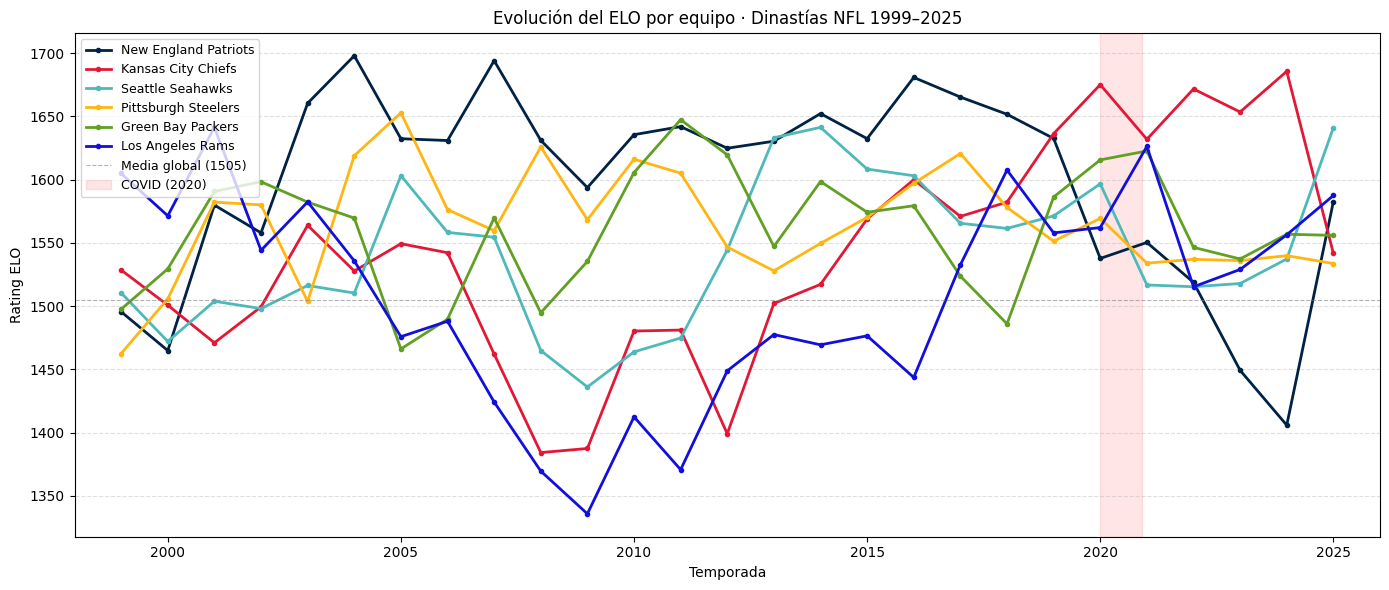

In [74]:
# Equipos con historia relevante 1999–2025
EQUIPOS = {
    'NE' : ('New England Patriots', '#002244'),
    'KC' : ('Kansas City Chiefs',   '#E31837'),
    'SEA': ('Seattle Seahawks',     "#4FB9BA"),
    'PIT': ('Pittsburgh Steelers',  '#FFB612'),
    'GB' : ('Green Bay Packers',    "#61A023"),
    'LA' : ('Los Angeles Rams',      "#120FDD")}

# ELO al cierre de cada temporada (último partido de cada equipo por season)
elo_season = (
    history_df
    .sort_values(['season', 'week'])
    .groupby(['season', 'home_team'])['elo_home_post']
    .last()
    .reset_index()
    .rename(columns={'home_team': 'team', 'elo_home_post': 'elo'})
)

# También capturar cuando son visitantes
elo_away = (
    history_df
    .sort_values(['season', 'week'])
    .groupby(['season', 'away_team'])['elo_away_post']
    .last()
    .reset_index()
    .rename(columns={'away_team': 'team', 'elo_away_post': 'elo'})
)

# Combinar y quedarse con el último valor por equipo/temporada
elo_all = pd.concat([elo_season, elo_away])
elo_season_final = (
    elo_all
    .sort_values('elo')
    .groupby(['season', 'team'])['elo']
    .last()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for team, (name, color) in EQUIPOS.items():
    data = elo_season_final[elo_season_final['team'] == team]
    ax.plot(data['season'], data['elo'],
            label=name, color=color, linewidth=2, marker='o', markersize=3)

ax.axhline(1505, color='gray', linestyle='--', linewidth=0.8,
           alpha=0.6, label='Media global (1505)')
ax.axvspan(2020, 2020.9, alpha=0.1, color='red', label='COVID (2020)')

ax.set_xlabel('Temporada')
ax.set_ylabel('Rating ELO')
ax.set_title('Evolución del ELO por equipo · Dinastías NFL 1999–2025')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(1998, 2026)

plt.tight_layout()
plt.show()

### Viz 2 · Rankings al cierre de 2025

Distribución de ratings al final de la última temporada disponible.
Los equipos sobre 1505 (línea de referencia) son considerados sobre
la media histórica de la liga.

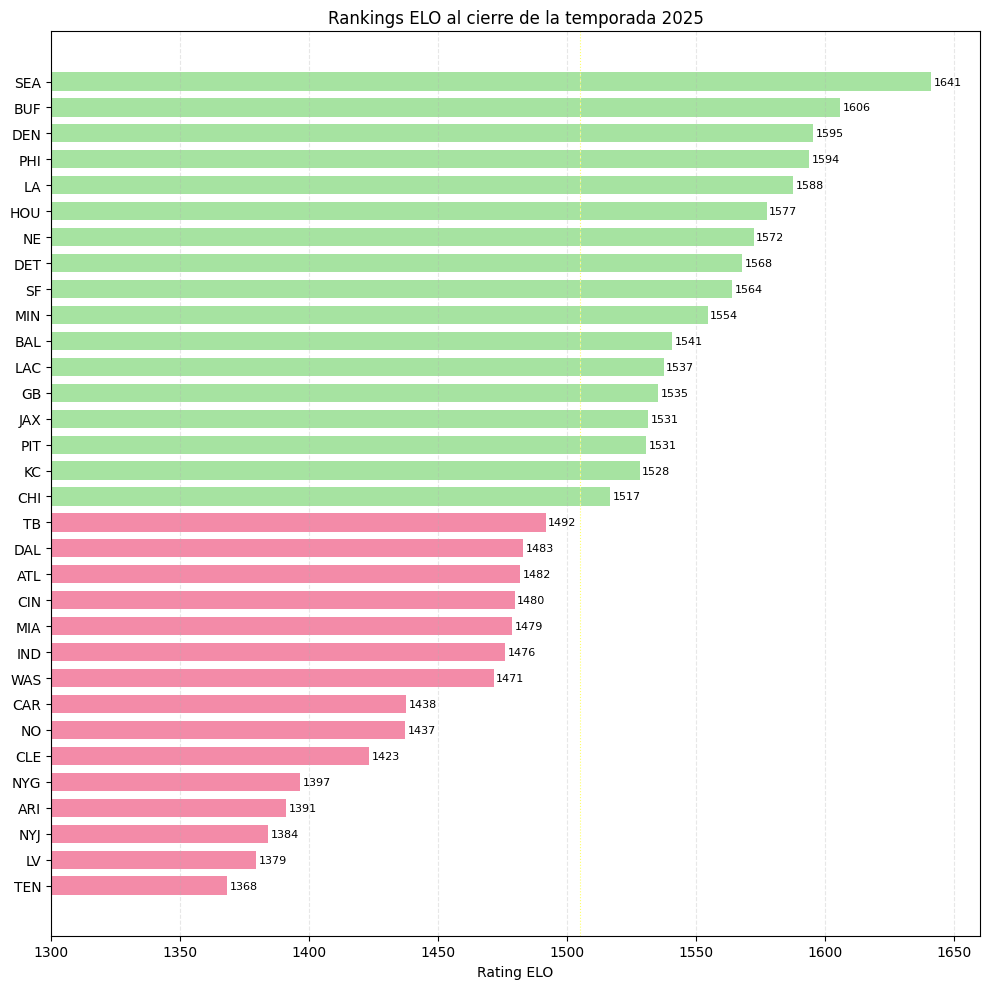

In [79]:
final_df = (
    pd.Series(final_elos)
    .reset_index()
    .rename(columns={'index': 'team', 0: 'elo'})
    .sort_values('elo', ascending=True)
)

colors = ['#a6e3a1' if e >= 1505 else '#f38ba8' for e in final_df['elo']]

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(final_df['team'], final_df['elo'], color=colors, height=0.7)
ax.axvline(1505, color='white', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(final_df['elo'].mean(), color='yellow',
           linestyle=':', linewidth=0.8, alpha=0.6)

# Etiquetas
for bar, val in zip(bars, final_df['elo']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

ax.set_xlabel('Rating ELO')
ax.set_title('Rankings ELO al cierre de la temporada 2025')
ax.set_xlim(1300, 1660)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Viz 3 · Calibration Curve

La calibration curve responde: *"cuando el modelo predice X%, ¿realmente
ocurre X% de las veces?"*

**Cómo leerla:**
- Puntos sobre la diagonal → modelo subestima (la realidad supera la predicción)
- Puntos bajo la diagonal → modelo sobreestima
- Diagonal perfecta → calibración ideal

Una desviación máxima de ~8 puntos porcentuales es aceptable. El modelo
logístico del Notebook 03 incorpora calibración implícita que debería
mejorar este resultado.

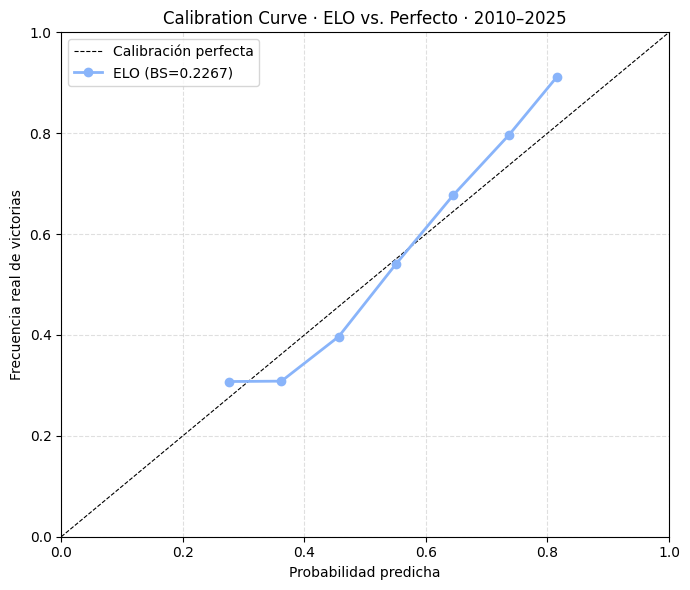

In [82]:
from sklearn.calibration import calibration_curve

# Usar período con Vegas para comparar ambas calibraciones
test = history_df[
    history_df['season'].isin(range(2010, 2026)) &
    history_df['game_type'].isin(['REG'])
].copy()

prob_true_elo, prob_pred_elo = calibration_curve(
    test['result'], test['p_home'], n_bins=10
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Calibración perfecta')
ax.plot(prob_pred_elo, prob_true_elo,
        'o-', color='#89b4fa', linewidth=2, markersize=6, label=f'ELO (BS={0.2267:.4f})')

ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia real de victorias')
ax.set_title('Calibration Curve · ELO vs. Perfecto · 2010–2025')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Viz 4 · Distribución histórica de ratings

Verificamos que la distribución de ratings ELO a lo largo del tiempo sea
aproximadamente normal y centrada cerca de 1505.

Una distribución con cola derecha pronunciada indica que el sistema acumula
puntos en equipos dominantes — comportamiento esperado en una liga con
dinámicas de poder tan marcadas como la NFL.

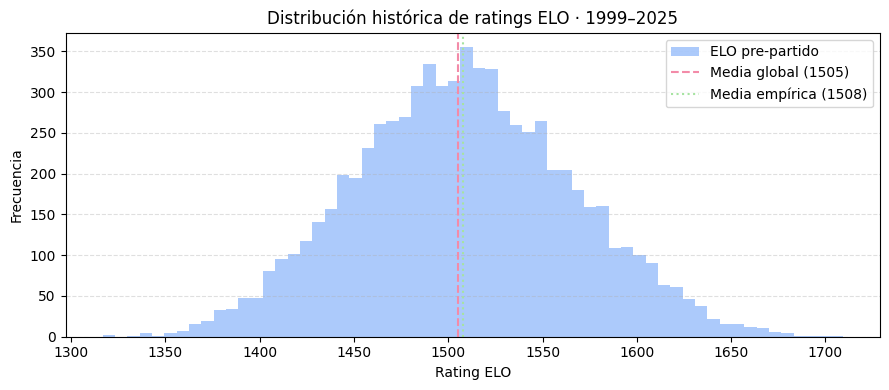

In [83]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(history_df['elo_home_pre'], bins=60,
        color='#89b4fa', alpha=0.7, label='ELO pre-partido')
ax.axvline(1505, color='#f38ba8', linestyle='--',
           linewidth=1.5, label='Media global (1505)')
ax.axvline(history_df['elo_home_pre'].mean(), color='#a6e3a1',
           linestyle=':', linewidth=1.5,
           label=f"Media empírica ({history_df['elo_home_pre'].mean():.0f})")

ax.set_xlabel('Rating ELO')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución histórica de ratings ELO · 1999–2025')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## §8 · Resumen y decisiones

### Parámetros confirmados

| Parámetro | Valor | Método de calibración |
|---|---|---|
| `HOME_ADVANTAGE` | 42.2 pts | Derivado del home win rate observado 1999–2025 |
| `K_REGULAR` | 20 | FiveThirtyEight (2014) · confirmado con backtesting |
| `K_PLAYOFFS` | 24 | K × 1.2 · mayor peso informativo por partido eliminatorio |
| `REGRESION` | 0.33 | FiveThirtyEight · validado históricamente |

### Resultados del backtesting

| Métrica | Valor |
|---|---|
| BS modelo nulo (50/50) | 0.2500 |
| **BS ELO (nuestro sistema)** | **0.2267** |
| BS Vegas (benchmark) | 0.2114 |
| Gap cerrado por ELO | 60.4% |
| Gap restante para Notebook 03 | 39.6% |


### Próximos pasos

El ELO solo cierra el 60% del gap contra Vegas. El **Notebook 03** agrega
features adicionales (home_rest, away_rest, div_game, week_norm) mediante
regresión logística para intentar cerrar parte del 40% restante.